---

Reconecte ao Drive.

In [2]:
import os
DRIVE_DIRECTORY = "curso_ml"
DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

---

In [3]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

## Regressão polinomial

Comece recuperando os dados previsores e alvo, de treino e de teste, a partir do arquivo `parkinson.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem que salvou.

In [4]:
with open(os.path.join(DRIVE_DIRECTORY, "parkinson.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

Instancie um transformador do tipo `PolynomialFeatures` com `degree=4`. Utilize ele para transformar os atributos previsores de treino e de teste.

In [5]:
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

Confira o `shape` dos dados previsores de treino, antes e depois de aplicar o transformador polinomial.

In [6]:
X_train.shape, X_train_poly.shape

((4406, 19), (4406, 8855))

Instancie um regressor linear, e treine utilizando as variáveis preditoras polinomiais.

In [7]:
lrp = LinearRegression()
lrp.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Calcule o score deste regressor com os dados de treino.

In [8]:
lrp.score(X_train_poly, y_train)

0.9999961087053593

E também com os dados de teste.

In [9]:
lrp.score(X_test_poly, y_test)

0.9991179593709321

Utilize o regressor para fazer predições baseadas nos dados de treinamento.

In [10]:
y_pred = lrp.predict(X_train_poly)

Exiba o erro absoluto médio para este split.

In [11]:
mean_absolute_error(y_train, y_pred)

3.339753837337293e-05

Exiba uma comparação da variável de treino entre os valores reais e preditos, na forma de um gráfico de linhas.

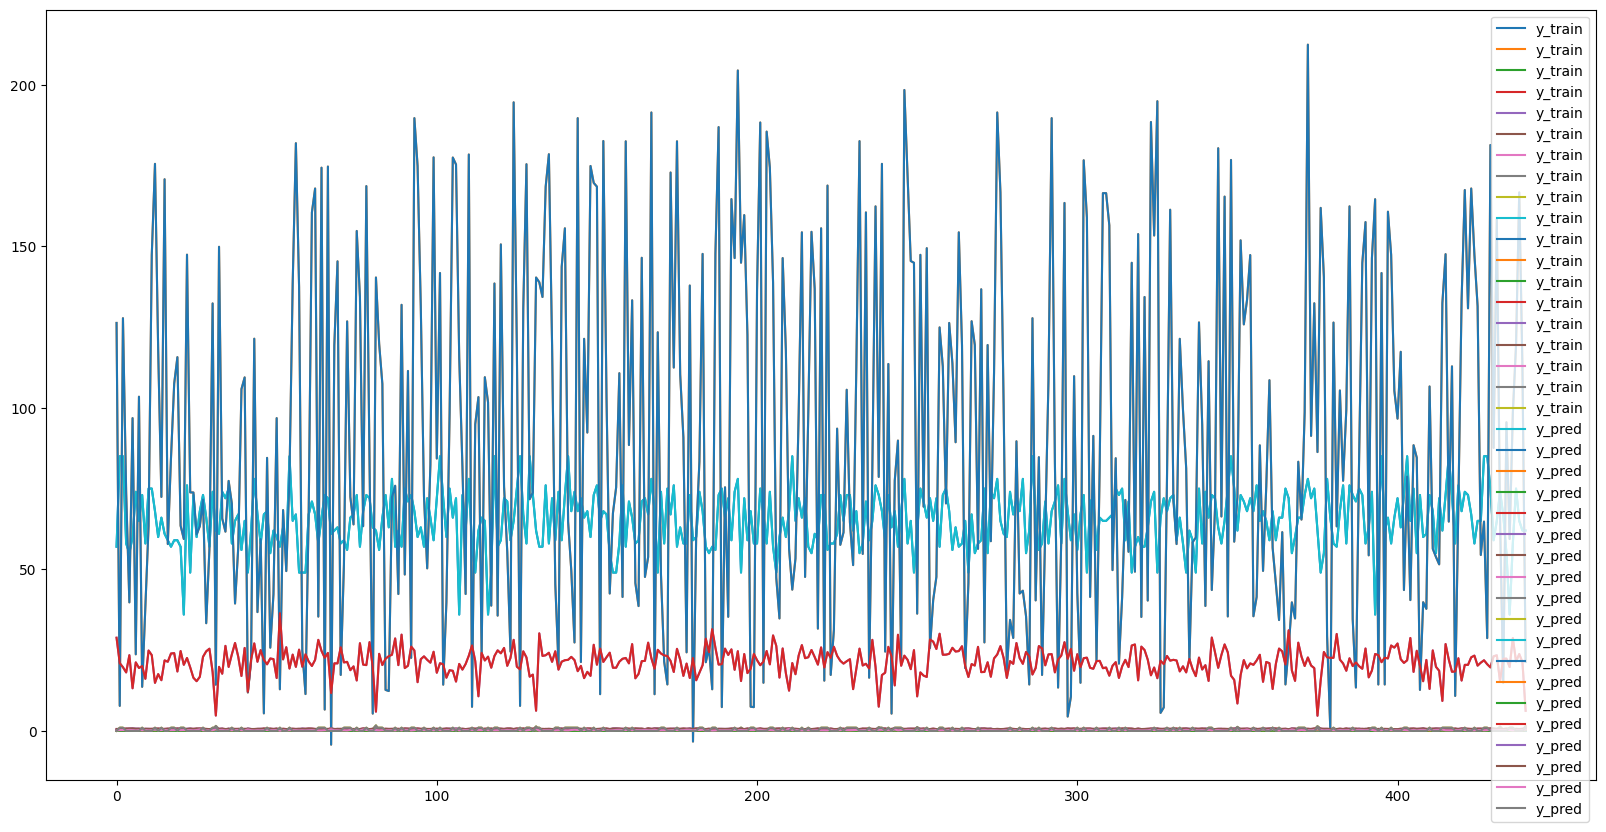

In [12]:
plt.figure(figsize=(20, 10))
plt.plot(y_train[::10], label="y_train")
plt.plot(y_pred[::10], label="y_pred")
plt.legend()

Tanto pelo score quanto pelo gráfico, é possível observar que, para os dados de treino, este preditor se saiu melhor do que a regressão linear múltipla da última sessão.

Agora faça predições para os dados de teste, exiba o erro absoluto médio e o gráfico de comparação.

In [13]:
y_pred = lrp.predict(X_test_poly)

In [14]:
mean_absolute_error(y_test, y_pred)

0.00014259330093117808

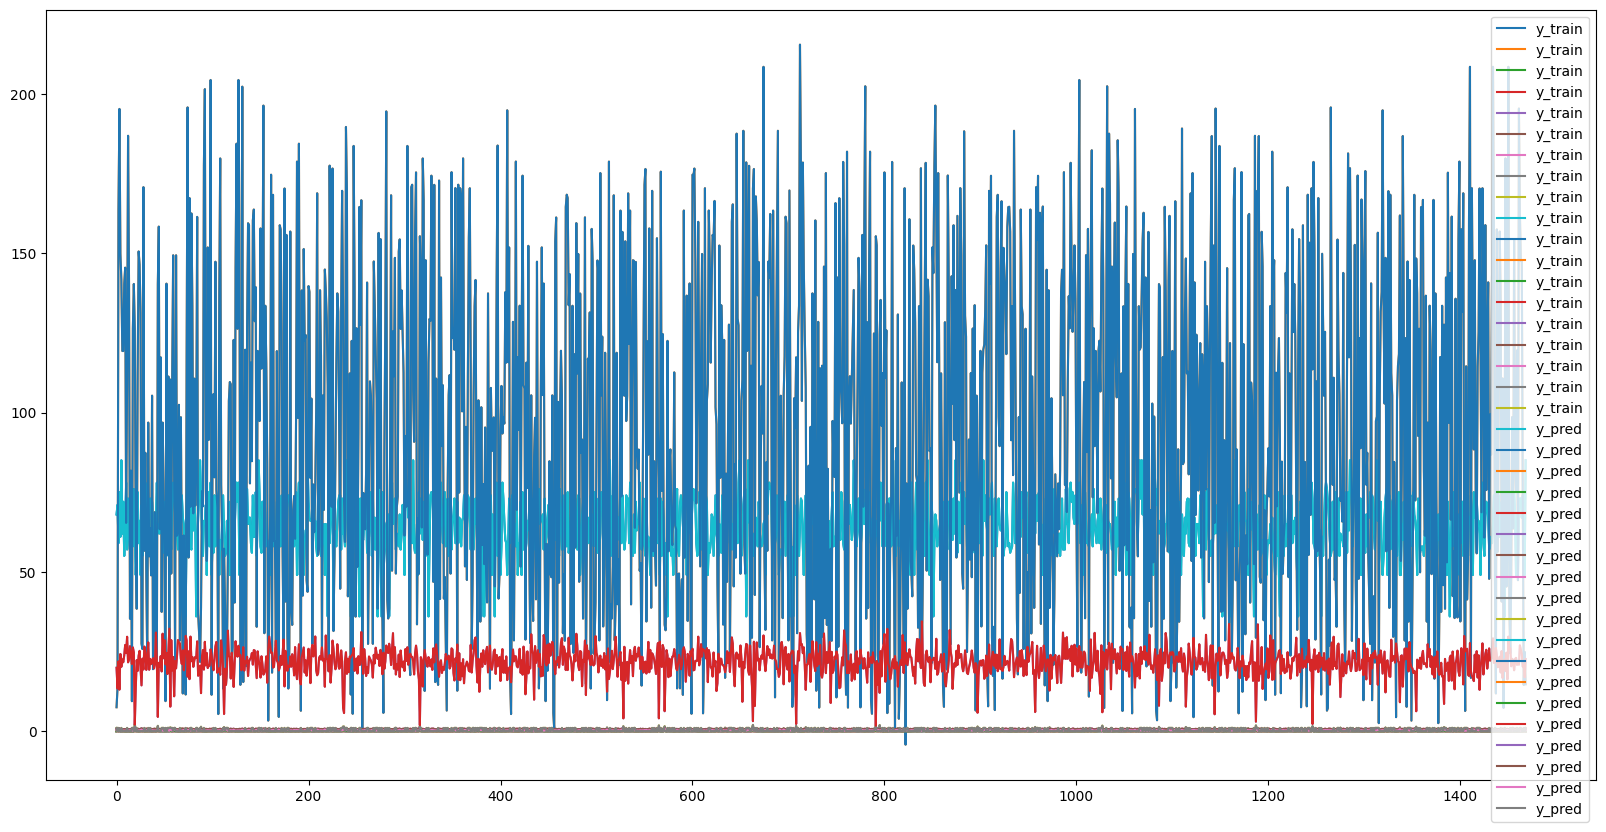

In [15]:
plt.figure(figsize=(20, 10))
plt.plot(y_test, label="y_train")
plt.plot(y_pred, label="y_pred")
plt.legend()

No split de teste, os resultados ficaram ainda piores do que o regressor linear, perceba que o novo regressor fez predições bastante extremas, por isso o gráfico parece achatado.

## Árvores de decisão

Instancie e treine um regressor do tipo árvore de decisão.

In [16]:
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

Exiba o score deste regressor para os dados de treinamento.

In [17]:
tree.score(X_train, y_train)

1.0

Este valor indica que as regressões ficaram perfeitas, coincidindo com os valores reais. Faça as predições para este split, exiba o erro absoluto médio e também a comparação no gráfico.

In [18]:
y_pred = tree.predict(X_train)

In [19]:
mean_absolute_error(y_train, y_pred)

0.0

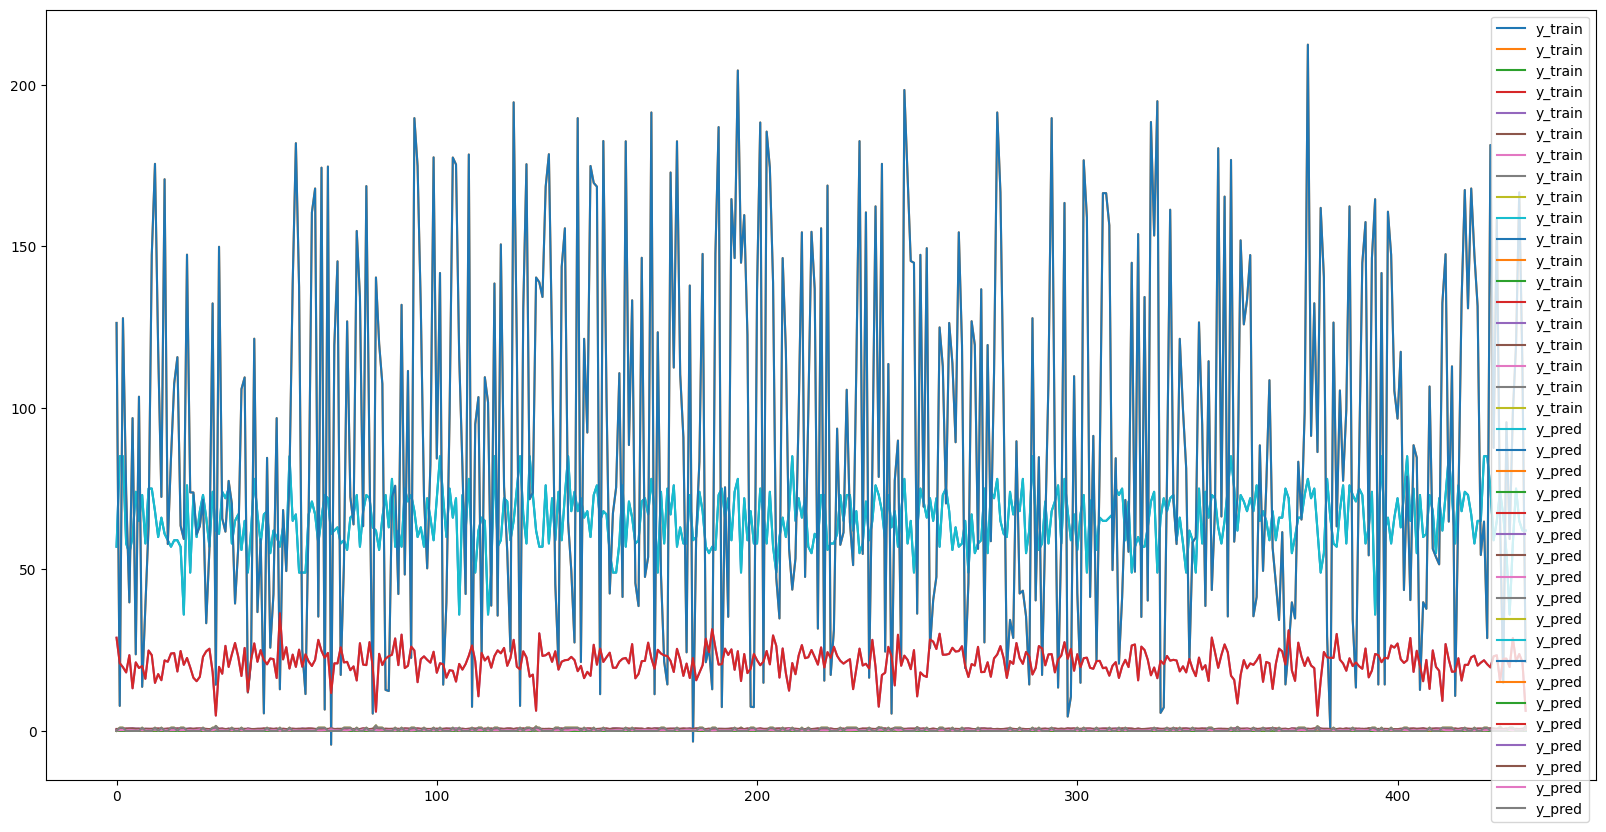

In [20]:
plt.figure(figsize=(20, 10))
plt.plot(y_train[::10], label="y_train")
plt.plot(y_pred[::10], label="y_pred")
plt.legend()

O erro é aproximadamente igual a zero, e o gráfico confirma predições alinhadas com os valores reais.

Agora repita o procedimento de avaliação para o split de teste.

In [21]:
tree.score(X_test, y_test)

0.5518500248849412

In [22]:
y_pred = tree.predict(X_test)

In [23]:
mean_absolute_error(y_test, y_pred)

0.1524298711325283

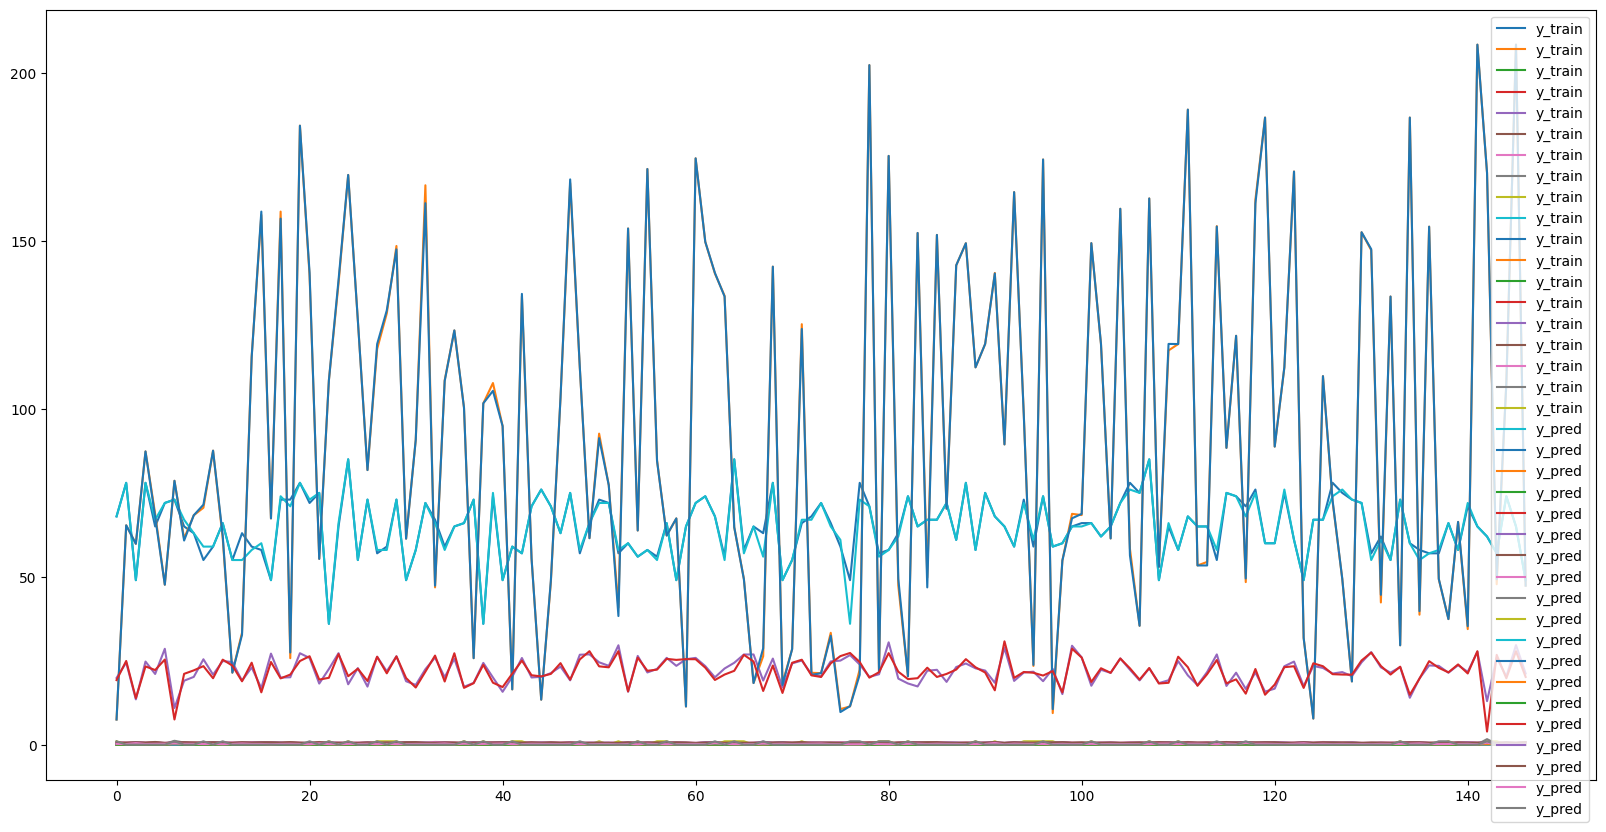

In [24]:
plt.figure(figsize=(20, 10))
plt.plot(y_test[::10], label="y_train")
plt.plot(y_pred[::10], label="y_pred")
plt.legend()

Como é normal, o desempenho no split de teste não ficou tão bom quanto no split de treinamento, mas ainda assim ficou excelente, com poucos valores preditos diferentes dos reais.

## RandomForest

Refaça o exercício agora utilizando um regressor do tipo Random Forest. Utilize `n_estimators=10`.

In [25]:
rf = RandomForestRegressor(n_estimators=10)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [26]:
rf.score(X_train, y_train)

0.9527087464332528

In [27]:
y_pred = rf.predict(X_train)

In [28]:
mean_absolute_error(y_train, y_pred)

0.055194375710382944

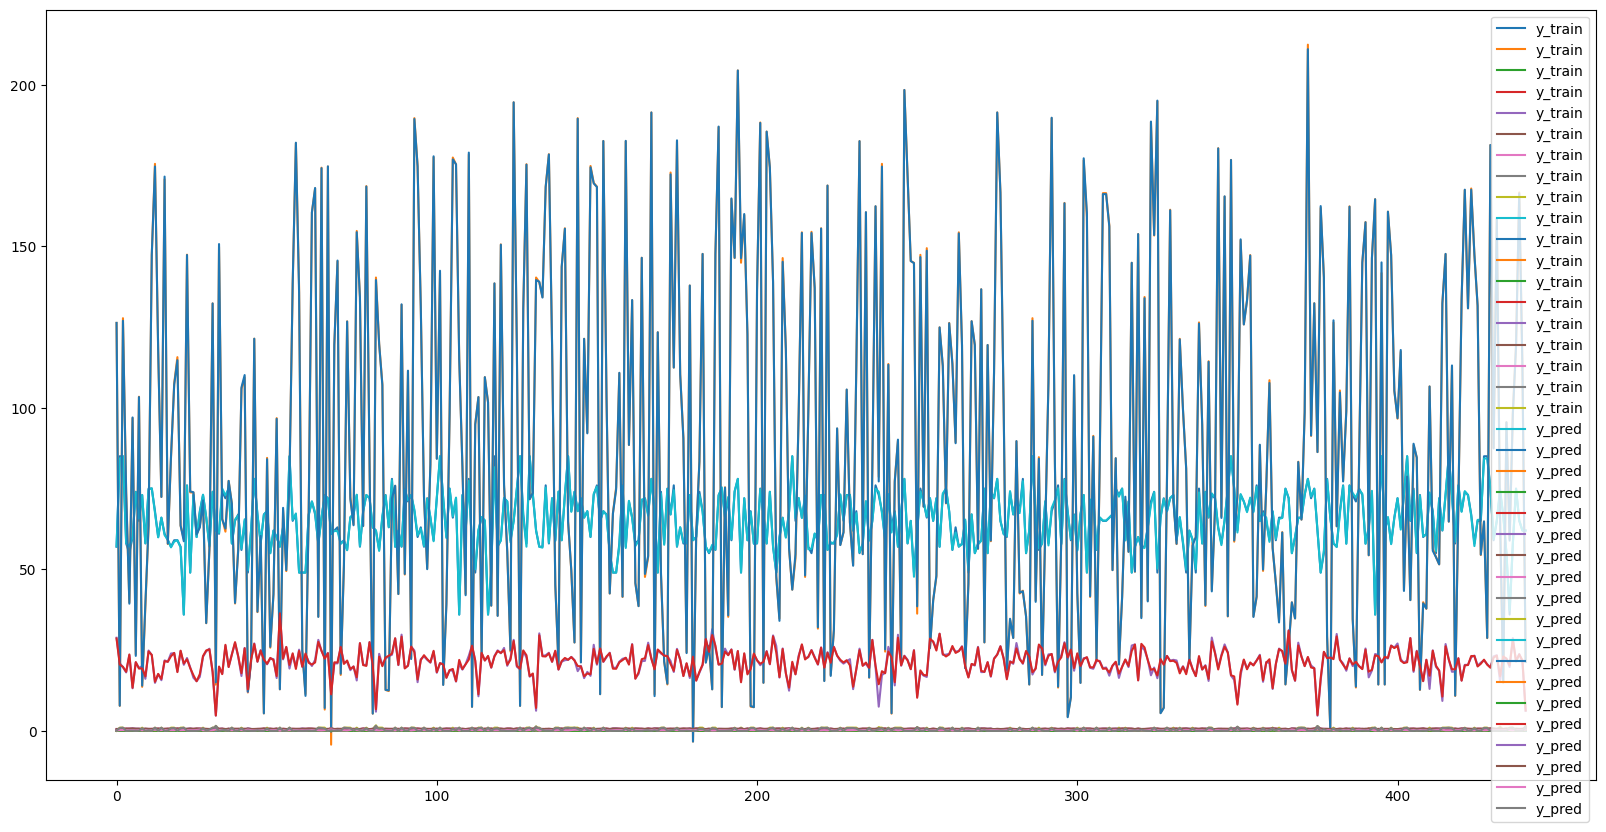

In [29]:
plt.figure(figsize=(20, 10))
plt.plot(y_train[::10], label="y_train")
plt.plot(y_pred[::10], label="y_pred")
plt.legend()

Este regressor ficou um pouco pior que a árvore de decisão no split de treinamento, mas ainda assim muito bom!

E no split de teste?

In [30]:
rf.score(X_test, y_test)

0.7510923635155285

In [31]:
y_pred = rf.predict(X_test)

In [32]:
mean_absolute_error(y_test, y_pred)

0.13315645680273017

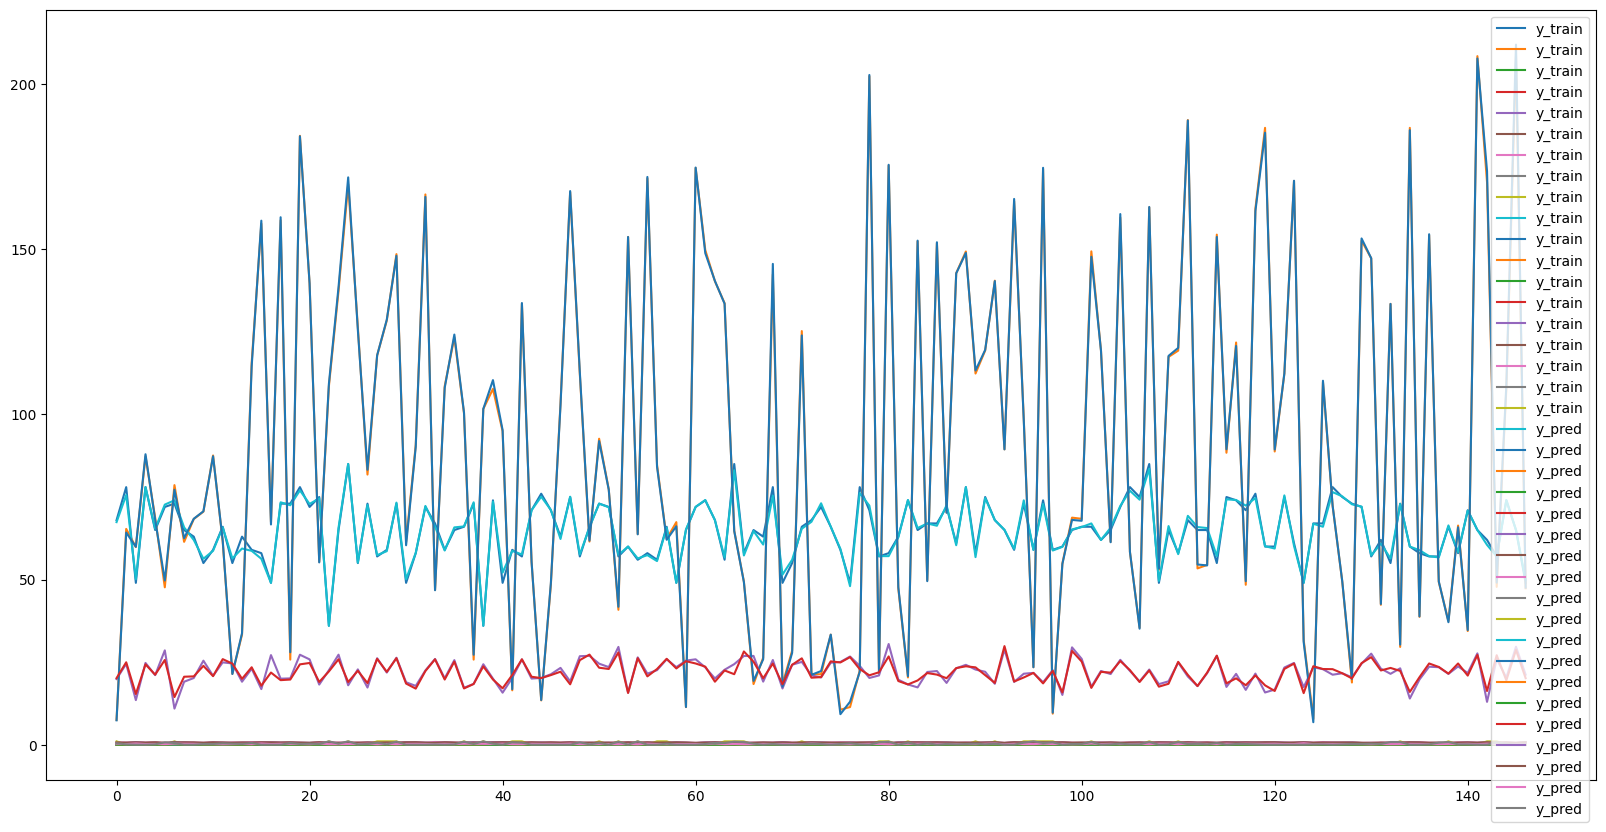

In [33]:
plt.figure(figsize=(20, 10))
plt.plot(y_test[::10], label="y_train")
plt.plot(y_pred[::10], label="y_pred")
plt.legend()

O score ficou um pouco melhor que a árvore de decisão, apesar de o erro médio ter ficado um pouco maior. Isso indica que, em média, o erro aumentou, mas temos menos valores extremos.

## SVM

Instancie um regressor do tipo SVM, com `kernel="linear"`, e ajuste com os dados de treino.

In [34]:
svr = SVR(kernel="linear")
svr.fit(X_train, y_train)

ValueError: y should be a 1d array, got an array of shape (4406, 19) instead.

Exiba o score para os dados de treino e de teste.

In [ ]:
svr.score(X_train, y_train)

0.14348590204709477

In [ ]:
svr.score(X_test, y_test)

0.12219989901078598

Este regressor não se saiu muito bem.

Instancie e treine outro regressor do tipo SVM, mas agora com `kernel="poly"` e `degree=4`.

In [ ]:
svr_poly = SVR(kernel="poly", degree=4)
svr_poly.fit(X_train, y_train)

SVR(degree=4, kernel='poly')

Exiba os scores.

In [ ]:
svr_poly.score(X_train, y_train)

0.04909745897454865

In [ ]:
svr_poly.score(X_test, y_test)

0.045542317536284016

O resultado ficou ainda pior.

Agora vamos tentar um regressor SVM com `kernel="rbf"`. Para isso, primeiro precisamos escalonar os valores.

Instancie um escalonador para os atributos previsores, e outro para o atributo alvo, ambos do tipo `StandardScaler`.

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

Agora escalone os dados de treinamento. Lembre-se que, no caso de `y`, você deve primeiro utilizar `reshape(-1, 1)`, para apresentá-los ao escalonador no formato coluna, e depois da transformação, voltar a linearizá-lo com `ravel()`.

In [ ]:
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

Transforme também os dados de teste.

In [ ]:
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

Agora sim instancie o regressor e ajuste com os dados escalonados.

In [ ]:
svr_rbf = SVR(kernel="rbf")
svr_rbf.fit(X_train_scaled, y_train_scaled)

SVR()

Exiba os scores do regressor.

In [ ]:
svr_rbf.score(X_train_scaled, y_train_scaled)

0.5004794038369794

In [ ]:
svr_rbf.score(X_test_scaled, y_test_scaled)

0.4630396752885664

Os resultados melhoraram em comparação aos outros kernels.

Utilize o regressor para fazer predições no split de teste. Depois, como esses dados estão escalonados, utilize o método `inverse_transform` do escalonador para retorná-los à escala original. Lembre-se dos cuidados com os `shape`s ao invocar o escalonador.

In [ ]:
y_pred = svr_rbf.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()

Agora exiba o erro absoluto médio para os dados de teste em sua escala original.

In [ ]:
mean_absolute_error(y_test, y_pred)

5.616380997616371

## Redes neurais artificiais

Instancie um regressor do tipo rede neural, com `max_iter=1000`. Treine este modelo com os dados escalonados.

In [ ]:
neural_net = MLPRegressor(max_iter=1000)
neural_net.fit(X_train_scaled, y_train_scaled)

MLPRegressor(max_iter=1000)

Exiba os scores do regressor.

In [ ]:
neural_net.score(X_train_scaled, y_train_scaled)

0.7856320693760486

In [ ]:
neural_net.score(X_test_scaled, y_test_scaled)

0.6723792442388028

Faça predições para os dados de teste. Lembre-se de, depois, retornar os valores preditos para sua escala original.

In [ ]:
y_pred = neural_net.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)

Exiba o erro absoluto médio para os dados de teste.

In [ ]:
mean_absolute_error(y_test, y_pred)

4.3285426745478315